In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import networkx as nx
import math
import random
from itertools import combinations
from collections import Counter
from graph_func import plot_nodes, plot_edges
from geopy.distance import geodesic
from tabulate import tabulate
import scipy.spatial.distance as distance
from decimal import Decimal, getcontext
from math import dist
import bz2
import geopandas as gpd
import time
import os
import pickle
from scipy import stats


Novas Redes Reais - ITDK/IPV4

* CARACTERIZAÇÕES

In [ ]:
df_europa = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\nodes_EU.csv"
df_europa = pd.read_csv(df_europa, sep=',', encoding='utf-8')

df_asia = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\nodes_AS.csv"
df_asia = pd.read_csv(df_asia, sep=',', encoding='utf-8')

df_america_do_sul = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\nodes_SA.csv"
df_america_do_sul = pd.read_csv(df_america_do_sul, sep=',', encoding='utf-8')

df_africa = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\nodes_AF.csv"
df_africa = pd.read_csv(df_africa, sep=',', encoding='utf-8')

df_oceania = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\nodes_OC.csv"
df_oceania = pd.read_csv(df_oceania, sep=',', encoding='utf-8')

df_america_do_norte = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\nodes_NA.csv"
df_america_do_norte = pd.read_csv(df_america_do_norte, sep=',', encoding='utf-8')




In [ ]:
df_america_do_norte

,inicial_node,final_node,continent_inicial,country_inicial,latitude_inicial,longitude_inicial,continent_final,country_final,latitude_final,longitude_final
0,N390099,N322024,NaN,US,34.05223,-118.24368,NaN,US,35.26757,-96.80335
1,N390099,N34244,NaN,US,34.05223,-118.24368,NaN,US,34.05223,-118.24368
2,N322024,N34244,NaN,US,35.26757,-96.80335,NaN,US,34.05223,-118.24368
3,N383797,N333924,NaN,US,37.44188,-122.14302,NaN,US,38.85233,-77.03720
4,N383797,N367350,NaN,US,37.44188,-122.14302,NaN,US,40.71427,-74.00597
...,...,...,...,...,...,...,...,...,...,...
147140,N127602,N68950,NaN,BS,24.31425,-75.45882,NaN,BS,24.31425,-75.45882
147141,N27235087,N68950,NaN,BS,24.31425,-75.45882,NaN,BS,24.31425,-75.45882
147142,N27235087,N374978,NaN,BS,24.31425,-75.45882,NaN,US,47.60621,-122.33207
147143,N27235088,N68950,NaN,BS,24.31425,-75.45882,NaN,BS,24.31425,-75.45882


*CRIAÇÃO DAS REDES*

In [ ]:
### Criação da Rede de Fibra
'''
G = nx.DiGraph()

# Adicionar todos os nós e arestas ao grafo
for _, row in df_america_do_norte.iterrows():
    # Adicionar nó inicial com atributos
    G.add_node(row['inicial_node'],
               continent=row['continent_inicial'],
               country=row['country_inicial'],
               longitude_inicial=row['longitude_inicial'],
               latitude_inicial=row['latitude_inicial'])


    # Adicionar nó final com atributos
    G.add_node(row['final_node'],
               continent=row['continent_final'],
               country=row['country_final'],
               longitude_final=row['longitude_final'],
               latitude_final=row['latitude_final'])

    # Adicionar aresta
    G.add_edge(row['inicial_node'], row['final_node'])

print(G.number_of_nodes())
print(G.number_of_edges())

pos = dict()

for node in G.nodes:
    lon_inicial = G.nodes[node]["longitude_inicial"]
    lat_inicial = G.nodes[node]["latitude_inicial"]
    lon_final = G.nodes[node]["longitude_final"]
    lat_final = G.nodes[node]["latitude_final"]

    pos[node] = (lon_inicial,lon_final, lat_inicial,lat_final) '''

def _transmissivity(d, gamma):  # noqa: F811
    """."""
    return 10 ** (-gamma * d / 10)


def _p_photon(d, gamma, n_p):
    """."""
    return 1 - (1 - _transmissivity(d, gamma)) ** n_p

G = nx.from_pandas_edgelist(
    df_america_do_norte,
    source='inicial_node',
    target='final_node',
    create_using=nx.DiGraph()
)

# Cria um dataframe com as informações dos nós de ORIGEM
df_source = df_america_do_norte[['inicial_node', 'continent_inicial', 'country_inicial', 'latitude_inicial', 'longitude_inicial']].rename(
    columns={'inicial_node': 'node_id', 'continent_inicial': 'continent', 'country_inicial': 'country',
             'latitude_inicial': 'lat', 'longitude_inicial': 'lon'}
)
# Cria um dataframe com as informações dos nós de DESTINO
df_target = df_america_do_norte[['final_node', 'continent_final', 'country_final', 'latitude_final', 'longitude_final']].rename(
    columns={'final_node': 'node_id', 'continent_final': 'continent', 'country_final': 'country',
             'latitude_final': 'lat', 'longitude_final': 'lon'}
)
# Combina os dois e remove duplicatas para ter uma lista única de nós
df_nodes_completos = pd.concat([df_source, df_target]).drop_duplicates(subset=['node_id']).reset_index(drop=True)
print(f"-> Catálogo de atributos únicos para {len(df_nodes_completos)} nós preparado.")



atributos_info = df_nodes_completos.set_index('node_id')[['continent', 'country']].to_dict('index')
nx.set_node_attributes(G, atributos_info)

# atributo 'pos'
pos_attributes = df_nodes_completos.set_index('node_id')[['lon', 'lat']].to_dict('index')
# Transforma o dicionário para o formato {node_id: (lon, lat)} que o 'pos' espera
pos_final = {node: (data['lon'], data['lat']) for node, data in pos_attributes.items()}
nx.set_node_attributes(G, pos_final, name='pos')

pos = nx.get_node_attributes(G, 'pos')
print("Nós:", G.number_of_nodes())
print("Arestas:", G.number_of_edges())
print(f"Nós com mais conexões :",sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10])


def rede_photonica(g_f, gamma, n_p):
    """
    Constrói uma rede fotônica a partir de uma rede de transporte.

    Parâmetros:
    g_f (nx.Graph): Rede de transporte.
    gamma (float): Coeficiente de atenuação.
    n_p (int): Número de fótons.

    Retorna:
    g_f (nx.Graph): Rede de transporte original.
    g_p (nx.Graph): Rede fotônica construída.
    """
    g_p = nx.Graph()
    g_p.add_nodes_from(g_f.nodes())
    nx.set_node_attributes(g_f, pos, name="pos")
    nx.set_node_attributes(g_p, pos, name="pos")

    metric = math.dist
    def dist(u, v):
        return metric(pos[u], pos[v])

    print(f"  Construindo a rede fotônica...")
    total_edges = g_f.number_of_edges()
    start_loop2 = time.time() # INÍCIO DO CONTADOR INTERNO

    for i, edge in enumerate(g_f.edges):

        if i % 20000 == 0 and i > 0:
            print(f"    -> Verificando aresta {i}/{total_edges}")

        d_uv = dist(edge[0], edge[1])
        p_uv = _p_photon(d_uv, gamma, n_p)
        p = np.random.rand()
        if p_uv >= p:
            g_p.add_edge(*edge)

    end_loop2 = time.time() # FIM DO CONTADOR INTERNO
    print(f"  -> Concluído em {end_loop2 - start_loop2:.2f} segundos.")

    return g_f, g_p


g_fiber_real, g_photon_real = rede_photonica(G, gamma=0.2, n_p=1000)
pos = nx.get_node_attributes(g_fiber_real, 'pos')

print("Rede de fibra:", g_fiber_real.number_of_nodes(), "nós e", g_fiber_real.number_of_edges(), "arestas.")
print("Rede fotônica:", g_photon_real.number_of_nodes(), "nós e", g_photon_real.number_of_edges(), "arestas.")





-> Catálogo de atributos únicos para 43957 nós preparado.
Nós: 43957
Arestas: 147145
Nós com mais conexões : [('N396486', 3381), ('N394921', 1842), ('N34244', 1756), ('N342857', 1191), ('N380491', 1106), ('N383318', 998), ('N383797', 959), ('N380611', 946), ('N395465', 904), ('N369353', 837)]
  Construindo a rede fotônica...
    -> Verificando aresta 20000/147145
    -> Verificando aresta 40000/147145
    -> Verificando aresta 60000/147145
    -> Verificando aresta 80000/147145
    -> Verificando aresta 100000/147145
    -> Verificando aresta 120000/147145
    -> Verificando aresta 140000/147145
  -> Concluído em 1.15 segundos.
Rede de fibra: 43957 nós e 147145 arestas.
Rede fotônica: 43957 nós e 129548 arestas.


In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais"
caminho_arquivo_gf = os.path.join(path_base, 'g_fiber_real_NA.pickle')
caminho_arquivo_gp = os.path.join(path_base, 'g_photon_real_NA.pickle')

# --- Salvar dados da Rede de Fibra (g_f) ---
try:
    # 2. Abrimos um arquivo em modo "write binary" (wb)
    with open(caminho_arquivo_gf, 'wb') as f:
        # 3. Usamos pickle.dump para salvar o objeto no arquivo
        pickle.dump(g_fiber_real, f, pickle.HIGHEST_PROTOCOL)
    print(f"-> Grafo de fibra (g_fiber_real) salvo em: {caminho_arquivo_gf}")

    # --- Salvar dados da Rede Fotônica (g_p) ---
    with open(caminho_arquivo_gp, 'wb') as f:
        pickle.dump(g_photon_real, f, pickle.HIGHEST_PROTOCOL)
    print(f"-> Grafo fotônico (g_photon_real) salvo em: {caminho_arquivo_gp}")

    print("\n--- Processo de salvamento concluído! ---")

except Exception as e:
    print(f"Ocorreu um erro ao salvar os arquivos: {e}")

-> Grafo de fibra (g_fiber_real) salvo em: C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\g_fiber_real_NA.pickle
-> Grafo fotônico (g_photon_real) salvo em: C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\g_photon_real_NA.pickle

--- Processo de salvamento concluído! ---



--- Gerando o gráfico de distribuição de graus ---


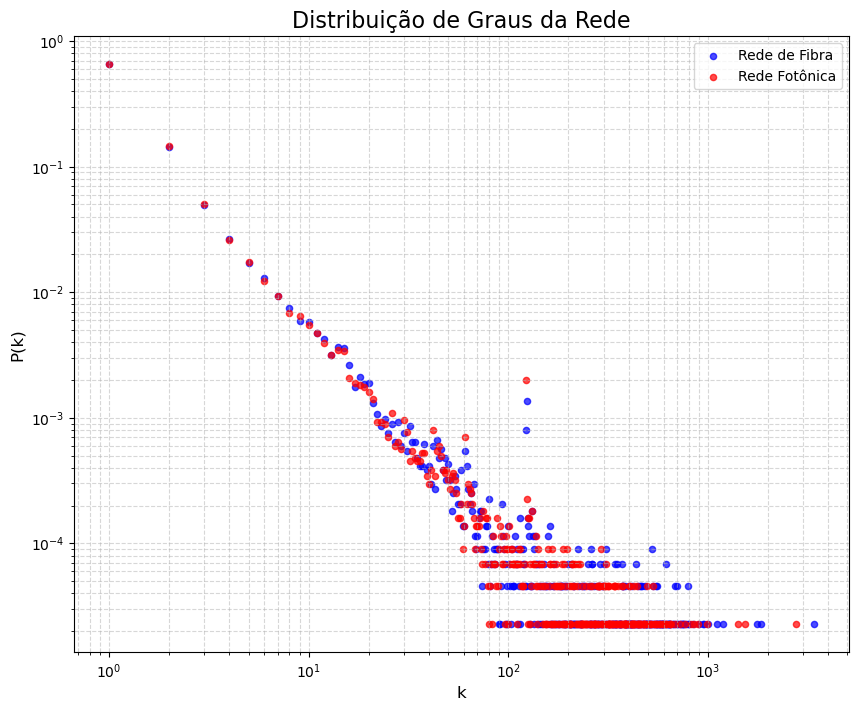

In [ ]:
def plotar_distribuicao_graus(ax, G, color, label):
    """
    Função auxiliar para calcular e plotar a distribuição de graus de um grafo.
    """
    # Pega o grau de cada nó no grafo
    degrees = [val for (node, val) in G.degree()]

    # Conta quantas vezes cada grau aparece
    degree_counts = Counter(degrees)

    # Separa os graus (k) e suas contagens
    k, count = zip(*degree_counts.items())

    # Calcula a probabilidade P(k) = (nós com grau k) / (total de nós)
    pk = [c / G.number_of_nodes() for c in count]

    # Plota k vs P(k) em um gráfico de dispersão
    ax.scatter(k, pk, color=color, label=label, alpha=0.7, s=20) # s é o tamanho dos pontos

# --- Criação do Gráfico ---

print("\n--- Gerando o gráfico de distribuição de graus ---")

# Cria a figura e os eixos para o plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plota a distribuição para a rede de fibra
plotar_distribuicao_graus(ax, g_fiber_real, color='blue', label='Rede de Fibra')

# Plota a distribuição para a rede fotônica no mesmo gráfico
plotar_distribuicao_graus(ax, g_photon_real, color='red', label='Rede Fotônica')

# --- Customização do Gráfico ---

# Define a escala dos eixos para logarítmica
ax.set_xscale('log')
ax.set_yscale('log')

# Adiciona títulos e legendas
ax.set_title("Distribuição de Graus da Rede", fontsize=16)
ax.set_ylabel("P(k)", fontsize=12)
ax.set_xlabel("k", fontsize=12)
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)

# Exibe o gráfico
plt.show()


Adpatar as Redes Soares, Samuraí e Scale-Free

Soares

In [ ]:
def _transmissivity(d, gamma):
    return 10 ** (-gamma * d / 10)


def _p_photon(d, gamma, n_p):
    return 1 - (1 - _transmissivity(d, gamma)) ** n_p


def soares_samurai(n, m, radius, alpha_a, gamma, n_p, seed = 0):
    """."""
    if m < 1 or m >= n:
        raise Exception("network must have m >= 1 and m < n")
    if alpha_a < 0:
        raise Exception("alpha_a must satisfy alpha_a >= 0")

    # Positioning of nodes
    radius_rand = np.sqrt(np.random.uniform(0, radius**2, n))
    theta_rand = np.random.uniform(0, 2 * np.pi, n)
    pos_x = radius_rand * np.cos(theta_rand)
    pos_y = radius_rand * np.sin(theta_rand)
    pos = np.vstack([pos_x, pos_y]).T

    g_f = nx.complete_graph(m + 1)

    # Positioning of incoming nodes
    print(f"  Construindo a rede de fibra (preferential attachment)...")
    start_loop1 = time.time() # INÍCIO DO CONTADOR INTERNO 1
    for new_node in range(m + 1, n):
        if new_node % 1000 == 0:
            print(f"    -> Adicionando nó {new_node}/{n}")

        degrees = np.array(list(dict(g_f.degree()).values()))
        dist = pos[:new_node] - pos[new_node]
        r_ij = np.sqrt(np.sum(dist**2, axis=1)) ** (-alpha_a)
        prob = degrees * r_ij
        prob_norm = prob / np.sum(prob)

        chosen = np.random.choice(
            list(g_f.nodes), size=m, replace=False, p=prob_norm
        )
        for node in chosen:
            g_f.add_edge(node, new_node)
    end_loop1 = time.time() # FIM DO CONTADOR INTERNO 1
    print(f"  -> Concluído em {end_loop1 - start_loop1:.2f} segundos.")

    # Creates the photonic network from fiber optics network
    g_p = nx.Graph()
    g_p.add_nodes_from(g_f.nodes())
    pos = {node: (pos_x[node], pos_y[node]) for node in range(n)}
    nx.set_node_attributes(g_f, pos, name="pos")
    nx.set_node_attributes(g_p, pos, name="pos")

    metric = math.dist
    def dist(u, v):
        return metric(pos[u], pos[v])

    print(f"  Construindo a rede fotônica...")
    total_edges = g_f.number_of_edges()
    start_loop2 = time.time() # INÍCIO DO CONTADOR INTERNO 2
    for i, edge in enumerate(g_f.edges):
        if i % 20000 == 0 and i > 0:
            print(f"    -> Verificando aresta {i}/{total_edges}")

        d_uv = dist(edge[0], edge[1])
        p_uv = _p_photon(d_uv, gamma, n_p)
        p = np.random.rand()
        if p_uv >= p:
            g_p.add_edge(*edge)
    end_loop2 = time.time() # FIM DO CONTADOR INTERNO 2
    print(f"  -> Concluído em {end_loop2 - start_loop2:.2f} segundos.")

    return g_f, g_p




# ========================================================================
# CHAMADA DA PRIMEIRA FUNÇÃO
# ========================================================================
n = 43957
R = 2804
m = 2
gamma = 0.2
n_p = 1000
alpha_a = 5

print("--- Executando o modelo soares_samurai ---")
start_total_soares = time.time() # INÍCIO DO CONTADOR GERAL
g_f, g_p = soares_samurai(n, m, R, alpha_a, gamma, n_p, seed=0)
end_total_soares = time.time() # FIM DO CONTADOR GERAL
pos = nx.get_node_attributes(g_f, 'pos')

duration_soares = end_total_soares - start_total_soares
print(f"--- Modelo soares_samurai finalizado em {duration_soares:.2f} segundos ({duration_soares/60:.2f} minutos) ---\n")

print("Nós(rede fibra):", g_f.number_of_nodes(), "Arestas:", g_f.number_of_edges())
print("Nós(rede photonica):", g_p.number_of_nodes(), "Arestas:", g_p.number_of_edges())


--- Executando o modelo soares_samurai ---
  Construindo a rede de fibra (preferential attachment)...
    -> Adicionando nó 1000/43957
    -> Adicionando nó 2000/43957
    -> Adicionando nó 3000/43957
    -> Adicionando nó 4000/43957
    -> Adicionando nó 5000/43957
    -> Adicionando nó 6000/43957
    -> Adicionando nó 7000/43957
    -> Adicionando nó 8000/43957
    -> Adicionando nó 9000/43957
    -> Adicionando nó 10000/43957
    -> Adicionando nó 11000/43957
    -> Adicionando nó 12000/43957
    -> Adicionando nó 13000/43957
    -> Adicionando nó 14000/43957
    -> Adicionando nó 15000/43957
    -> Adicionando nó 16000/43957
    -> Adicionando nó 17000/43957
    -> Adicionando nó 18000/43957
    -> Adicionando nó 19000/43957
    -> Adicionando nó 20000/43957
    -> Adicionando nó 21000/43957
    -> Adicionando nó 22000/43957
    -> Adicionando nó 23000/43957
    -> Adicionando nó 24000/43957
    -> Adicionando nó 25000/43957
    -> Adicionando nó 26000/43957
    -> Adicionando nó 2

In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais"
caminho_arquivo_gf = os.path.join(path_base, 'soares_fibra.pickle')
caminho_arquivo_gp = os.path.join(path_base, 'soares_photonica.pickle')

# --- Salvar dados da Rede de Fibra (g_f) ---
try:
    # 2. Abrimos um arquivo em modo "write binary" (wb)
    with open(caminho_arquivo_gf, 'wb') as f:
        # 3. Usamos pickle.dump para salvar o objeto no arquivo
        pickle.dump(g_f, f, pickle.HIGHEST_PROTOCOL)
    print(f"-> Grafo de fibra (g_f) salvo em: {caminho_arquivo_gf}")

    # --- Salvar dados da Rede Fotônica (g_p) ---
    with open(caminho_arquivo_gp, 'wb') as f:
        pickle.dump(g_p, f, pickle.HIGHEST_PROTOCOL)
    print(f"-> Grafo fotônico (g_p) salvo em: {caminho_arquivo_gp}")

    print("\n--- Processo de salvamento concluído! ---")

except Exception as e:
    print(f"Ocorreu um erro ao salvar os arquivos: {e}")

-> Grafo de fibra (g_f) salvo em: C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\soares_fibra.pickle
-> Grafo fotônico (g_p) salvo em: C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\soares_photonica.pickle

--- Processo de salvamento concluído! ---


Waxman_Samuraí

In [ ]:
def _transmissivity(d, gamma):
    return 10 ** (-gamma * d / 10)


def _p_photon(d, gamma, n_p):
    return 1 - (1 - _transmissivity(d, gamma)) ** n_p

def waxman_samurai(nr_nodes, radius, alphaL, beta, gamma, n_p, seed = 0):
    """."""
    g_fiber = nx.empty_graph(nr_nodes)
    g_photonic = nx.empty_graph(nr_nodes)

    radius_rand = np.sqrt(np.random.uniform(0, radius**2, nr_nodes))
    theta_rand = np.random.uniform(0, 2 * np.pi, nr_nodes)
    pos_x = radius_rand * np.cos(theta_rand)
    pos_y = radius_rand * np.sin(theta_rand)
    pos = {node: (pos_x[node], pos_y[node]) for node in g_fiber}

    nx.set_node_attributes(g_fiber, pos, "pos")
    nx.set_node_attributes(g_photonic, pos, "pos")

    metric = math.dist
    def dist(u, v):
        return metric(pos[u], pos[v])
    def should_join(pair):
        return np.random.rand() < beta * np.exp(-dist(*pair) / (alphaL))

    print("  Construindo a rede de fibra (modelo Waxman)")
    all_possible_edges = combinations(g_fiber, 2)
    total_combinations = (nr_nodes * (nr_nodes - 1)) // 2

    start_loop1_waxman = time.time() # INÍCIO DO CONTADOR INTERNO 1
    for i, pair in enumerate(all_possible_edges):
        if i % 5_000_000 == 0 and i > 0:
            print(f"    -> Verificando par de nós {i:,}/{total_combinations:,}")

        if should_join(pair):
            g_fiber.add_edge(*pair)
    end_loop1_waxman = time.time() # FIM DO CONTADOR INTERNO 1
    print(f"  -> Concluído em {end_loop1_waxman - start_loop1_waxman:.2f} segundos.")

    print("  Construindo a rede fotônica...")
    total_edges = g_fiber.number_of_edges()
    start_loop2_waxman = time.time() # INÍCIO DO CONTADOR INTERNO 2
    for i, edge in enumerate(g_fiber.edges):
        if i % 20000 == 0 and i > 0:
            print(f"    -> Verificando aresta {i}/{total_edges}")

        d_uv = dist(edge[0], edge[1])
        p_uv = _p_photon(d_uv, gamma, n_p)
        p = np.random.rand()
        if p_uv >= p:
            g_photonic.add_edge(*edge)
    end_loop2_waxman = time.time() # FIM DO CONTADOR INTERNO 2
    print(f"  -> Concluído em {end_loop2_waxman - start_loop2_waxman:.2f} segundos.")

    return g_fiber, g_photonic

# ========================================================================
# CHAMADA DA SEGUNDA FUNÇÃO
# =================================
N = 43957
R = 1800
alphaL = 226
beta = 1
gamma = 0.2
n_p = 1000

print("--- Executando o modelo waxman_samurai ---")
start_total_waxman = time.time() # INÍCIO DO CONTADOR GERAL
G_fiber, G_photonic = waxman_samurai(N, R, alphaL, beta, gamma, n_p, seed = 0)
end_total_waxman = time.time() # FIM DO CONTADOR GERAL
pos = nx.get_node_attributes(G_fiber, 'pos')

duration_waxman = end_total_waxman - start_total_waxman
print(f"--- Modelo waxman_samurai finalizado em {duration_waxman:.2f} segundos ({duration_waxman/60:.2f} minutos) ---")

print("Nós(rede fibra):", G_fiber.number_of_nodes(), "Arestas:", G_fiber.number_of_edges())
print("Nós(rede photonica):", G_photonic.number_of_nodes(), "Arestas:", G_photonic.number_of_edges())

In [ ]:
### Salvar os dados da rede em .pickle

path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\samuraí_fibra.pickle"
path_base2 = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\samuraí_photonica.pickle"

caminho_arquivo_gf = os.path.join(path_base)
caminho_arquivo_gp = os.path.join(path_base2)

print("Carregando arquivos .pickle...")

try:
    # Abre o arquivo em modo "read binary" (rb)
    with open(caminho_arquivo_gf, 'rb') as f:
        G_fibra_carregado = pickle.load(f)

    with open(caminho_arquivo_gp, 'rb') as f:
        G_photonic_carregado = pickle.load(f)

    print("-> Grafos carregados com sucesso!")

    # Verificação
    print("\n--- Verificando os Grafos Carregados ---")
    print(f"Rede de fibra carregada: Nós: {G_fibra_carregado.number_of_nodes()}, Arestas: {G_fibra_carregado.number_of_edges()}")
    print(f"Rede fotônica carregada: Nós: {G_photonic_carregado.number_of_nodes()}, Arestas: {G_photonic_carregado.number_of_edges()}")

except Exception as e:
    print(f"Ocorreu um erro ao carregar os arquivos: {e}")

Scale_Free

In [ ]:
def _transmissivity(d, gamma):
    return 10 ** (-gamma * d / 10)


def _p_photon(d, gamma, n_p):
    return 1 - (1 - _transmissivity(d, gamma)) ** n_p

def scale_free_on_disc(
    n, radius, scale, exponent, gamma, n_p, k_domain=(3, 1e4), seed=None
):
    """Gera redes scale-free em um disco com acompanhamento de processo."""
    rng = np.random.default_rng(seed)
    m, K = k_domain

    print("  Iniciando a geração da rede...")

    def _generate_connectivity(random_val):
        """Cumulative distribution function for P(k)=Ck^{-exponent}."""
        k = round(m * (1 - random_val) ** (1 / (1 - exponent)))
        return min(max(k, m), K)

    # Etapa de posicionamento (rápida, não precisa de print)
    radius_rand = np.sqrt(rng.uniform(0, radius**2, n))
    theta_rand = rng.uniform(0, 2 * np.pi, n)
    pos_x = radius_rand * np.cos(theta_rand)
    pos_y = radius_rand * np.sin(theta_rand)
    pos = np.vstack([pos_x, pos_y]).T

    # --- ACOMPANHAMENTO 1: Geração de Conectividade ---
    print(f"  (1/4) Gerando conectividade para {n} nós...")
    random_list = rng.random(pos.shape[0])
    # Convertido para loop 'for' para permitir o print
    connectivity = []
    for i, val in enumerate(random_list):
        if (i + 1) % 5000 == 0 or i == n - 1:
            print(f"    -> Conectividade para o nó {i + 1}/{n}")
        connectivity.append(_generate_connectivity(val))

    g_f_free = nx.Graph()
    # Adiciona nós (etapa rápida)
    for i, pos_i in enumerate(pos):
        g_f_free.add_node(i, pos=pos_i, k=connectivity[i])
    print("  -> Nós adicionados ao grafo.")

    # --- ACOMPANHAMENTO 2: Criação da Rede de Fibra ---
    print(f"  (2/4) Criando arestas da rede de fibra (pode demorar)...")
    for i, pos_i in enumerate(pos):
        if (i + 1) % 1000 == 0 or i == n - 1:
            print(f"    -> Processando vizinhança do nó {i + 1}/{n}")

        k_i = connectivity[i]
        r_i = scale * np.sqrt(k_i)
        distances = np.linalg.norm(pos - pos_i, axis=1)

        neighbors = np.argsort(distances)
        neighbors = neighbors[
            (distances[neighbors] <= r_i) & (distances[neighbors] > 0)
        ]

        for j in neighbors:
            if g_f_free.degree[i] < k_i and g_f_free.degree[j] < connectivity[j]:
                g_f_free.add_edge(i, j)

    print("  -> Rede de fibra criada.")

    # Etapa de preparação da rede fotônica (rápida)
    g_p_free = nx.Graph()
    g_p_free.add_nodes_from(g_f_free.nodes())

    pos_dict = {i: (x, y) for i, (x, y) in enumerate(pos)}
    nx.set_node_attributes(g_f_free, pos_dict, "pos")
    nx.set_node_attributes(g_p_free, pos_dict, "pos")

    # Renomeando math.dist para evitar conflito
    metric = math.dist
    def dist(u, v):
        return metric(pos_dict[u], pos_dict[v])

    # --- ACOMPANHAMENTO 3: Criação da Rede Fotônica ---
    print(f"  (3/4) Criando arestas da rede fotônica...")
    total_edges = g_f_free.number_of_edges()
    for i, (u, v) in enumerate(g_f_free.edges):
        if (i + 1) % 20000 == 0 or (i + 1) == total_edges:
            print(f"    -> Processando aresta fotônica {i + 1}/{total_edges}")

        d_uv = dist(u, v)
        p_uv = _p_photon(d_uv, gamma, n_p)
        p = rng.random()
        if p_uv >= p:
            g_p_free.add_edge(u, v)

    print("  (4/4) Finalizando a criação dos grafos.")
    return g_f_free, g_p_free

# --- CHAMADA DA FUNÇÃO ---

n = 43957 # Número de nós
R = 2804  # Disc radius [km]
lambda_ = 2.5  # Distribution exponent
m = 3  # Minimum connectivity
K = 1e4  # Maximum connectivity
A = 100  # Model Constant
gamma = 0.2  # Fiber loss coefficient [dB/km]
n_p = 1000  # Number of photons

g_f_free, g_p_free = scale_free_on_disc(n=n, radius=R, scale=A, exponent=lambda_, gamma=gamma, n_p=1000, k_domain=(3, 1e4))
pos = nx.get_node_attributes(g_f_free, 'pos')

print("Nós(rede fibra):", g_f_free.number_of_nodes(), "Arestas:", g_f_free.number_of_edges())
print("Nós(rede photonica):", g_p_free.number_of_nodes(), "Arestas:", g_p_free.number_of_edges())



  Iniciando a geração da rede...
  (1/4) Gerando conectividade para 43957 nós...
    -> Conectividade para o nó 5000/43957
    -> Conectividade para o nó 10000/43957
    -> Conectividade para o nó 15000/43957
    -> Conectividade para o nó 20000/43957
    -> Conectividade para o nó 25000/43957
    -> Conectividade para o nó 30000/43957
    -> Conectividade para o nó 35000/43957
    -> Conectividade para o nó 40000/43957
    -> Conectividade para o nó 43957/43957
  -> Nós adicionados ao grafo.
  (2/4) Criando arestas da rede de fibra (pode demorar)...
    -> Processando vizinhança do nó 1000/43957
    -> Processando vizinhança do nó 2000/43957
    -> Processando vizinhança do nó 3000/43957
    -> Processando vizinhança do nó 4000/43957
    -> Processando vizinhança do nó 5000/43957
    -> Processando vizinhança do nó 6000/43957
    -> Processando vizinhança do nó 7000/43957
    -> Processando vizinhança do nó 8000/43957
    -> Processando vizinhança do nó 9000/43957
    -> Processando v

In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais"
caminho_arquivo_gf = os.path.join(path_base, 'scale_free_fibra.pickle')
caminho_arquivo_gp = os.path.join(path_base, 'scale_free_photonica.pickle')

# --- Salvar dados da Rede de Fibra (g_f) ---
try:
    # 2. Abrimos um arquivo em modo "write binary" (wb)
    with open(caminho_arquivo_gf, 'wb') as f:
        # 3. Usamos pickle.dump para salvar o objeto no arquivo
        pickle.dump(g_f_free, f, pickle.HIGHEST_PROTOCOL)
    print(f"-> Grafo de fibra (g_f) salvo em: {caminho_arquivo_gf}")

    # --- Salvar dados da Rede Fotônica (g_p) ---
    with open(caminho_arquivo_gp, 'wb') as f:
        pickle.dump(g_p_free, f, pickle.HIGHEST_PROTOCOL)
    print(f"-> Grafo fotônico (g_p) salvo em: {caminho_arquivo_gp}")

    print("\n--- Processo de salvamento concluído! ---")

except Exception as e:
    print(f"Ocorreu um erro ao salvar os arquivos: {e}")

print("Nós(rede fibra):", g_f_free.number_of_nodes(), "Arestas:", g_f_free.number_of_edges())
print("Nós(rede photonica):", g_p_free.number_of_nodes(), "Arestas:", g_p_free.number_of_edges())

-> Grafo de fibra (g_f) salvo em: C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\scale_free_fibra.pickle
-> Grafo fotônico (g_p) salvo em: C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais\scale_free_photonica.pickle

--- Processo de salvamento concluído! ---
Nós(rede fibra): 43957 Arestas: 183471
Nós(rede photonica): 43957 Arestas: 138673


*CARACTERIZAÇÕES DAS REDES*

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'soares_photonica.pickle' carregado com sucesso.
-> Arquivo 'samuraí_photonica.pickle' carregado com sucesso.
-> Arquivo 'scale_free_photonica.pickle' carregado com sucesso.
-> Arquivo 'g_photon_real_NA.pickle' carregado com sucesso.

--- Diagnóstico dos Grafos Carregados ---
- Soares-Samurai Fotônica: 43957 nós, 85910 arestas.
- Waxman-Samurai Fotônica: 43957 nós, 2002257 arestas.
- Scale-Free Fotônica: 43957 nós, 155607 arestas.
- g_photonica_real(NA): 43957 nós, 129548 arestas.

--- Gerando o gráfico com aparência uniforme ---


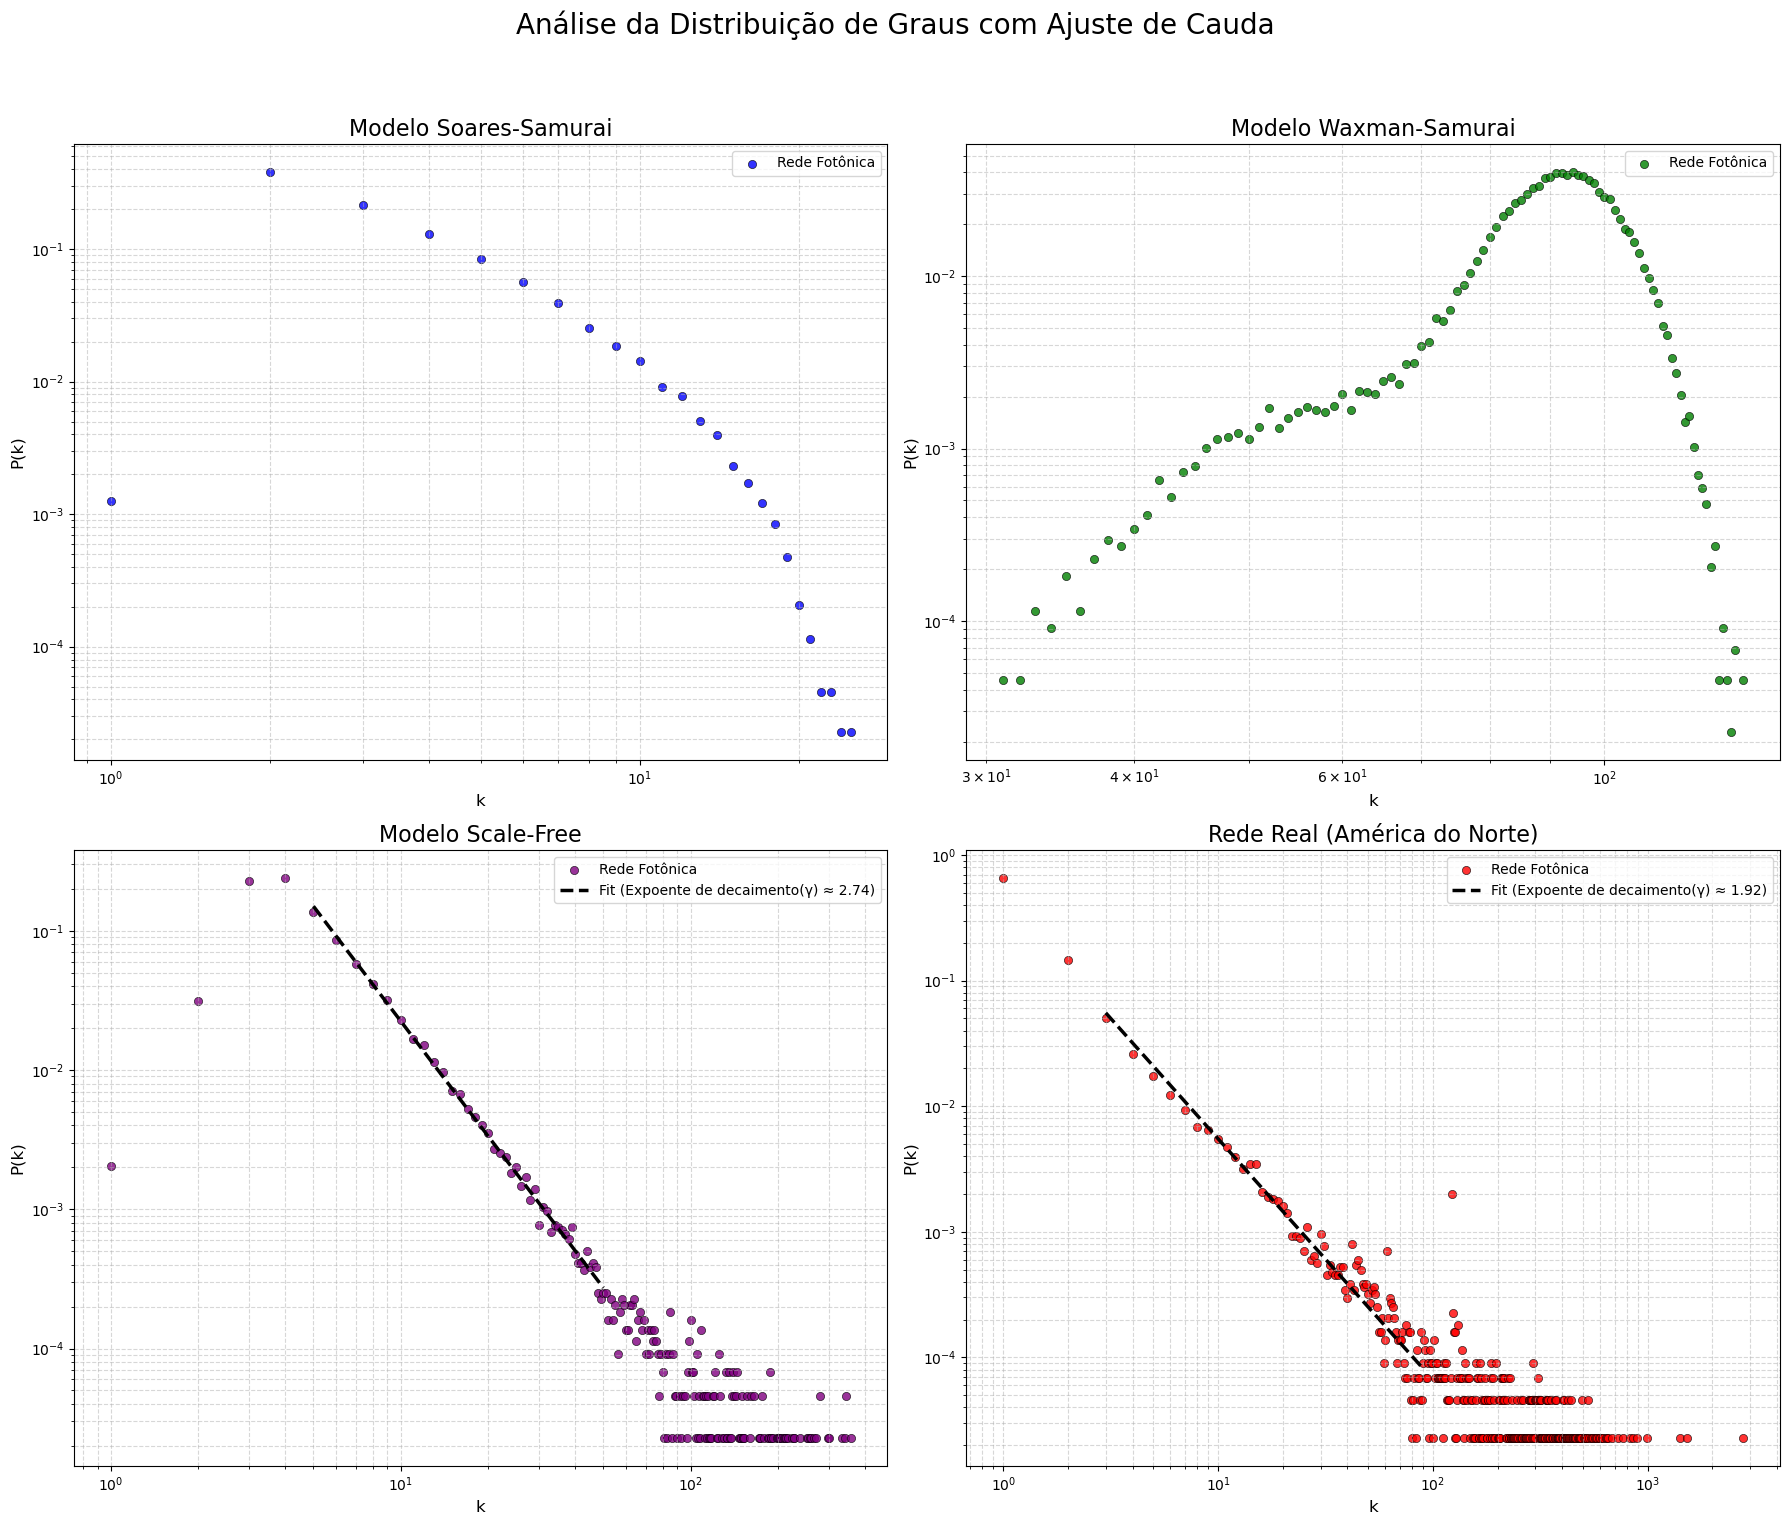

In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais"
arquivos_de_grafos = {
    'Soares-Samurai Fotônica': os.path.join(path_base, 'soares_photonica.pickle'),
    'Waxman-Samurai Fotônica': os.path.join(path_base, 'samuraí_photonica.pickle'),
    'Scale-Free Fotônica': os.path.join(path_base, 'scale_free_photonica.pickle'),
    'g_photonica_real(NA)': os.path.join(path_base, 'g_photon_real_NA.pickle')
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            grafos_carregados[nome] = pickle.load(f)
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado com sucesso.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo '{os.path.basename(caminho)}' não encontrado.")
        grafos_carregados[nome] = nx.Graph()


# --- ETAPA 1.5 (NOVA): Diagnóstico dos Grafos Carregados ---
print("\n--- Diagnóstico dos Grafos Carregados ---")
for nome, G in grafos_carregados.items():
    if G:
        print(f"- {nome}: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas.")
    else:
        print(f"- {nome}: Grafo não encontrado ou vazio.")

# --- Etapa 2 (ATUALIZADA): Função de Plotagem com k_min e k_max ---

def calcular_e_plotar_fit(ax, G, color, label_prefix, k_min=2, k_max=None):
    """
    Calcula e plota a distribuição de graus com aparência uniforme e
    ajusta a lei de potência apenas na janela [k_min, k_max].
    """
    if not G or G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, 'Grafo Vazio', ha='center', va='center', transform=ax.transAxes)
        return

    degrees = [val for (node, val) in G.degree() if val > 0]
    if not degrees:
        ax.text(0.5, 0.5, 'Rede sem arestas', ha='center', va='center', transform=ax.transAxes)
        return

    degree_counts = Counter(degrees)
    k_full, count_full = zip(*sorted(degree_counts.items()))
    pk_full = [c / G.number_of_nodes() for c in count_full]

    # --- MUDANÇA PRINCIPAL ---
    # 1. Plota TODOS os pontos de uma só vez com aparência uniforme e legenda simples.
    ax.scatter(k_full, pk_full, color=color, alpha=0.8, s=35,
               edgecolors='black', linewidths=0.5, label=label_prefix)

    # --- Cálculo do Expoente (na janela k_min, k_max) ---
    fit_data = {
        k: pk for k, pk in zip(k_full, pk_full)
        if k >= k_min and (k_max is None or k <= k_max)
    }

    if len(fit_data) > 1:
        k_fit, pk_fit = zip(*sorted(fit_data.items()))
        try:
            log_k = np.log10(k_fit)
            log_pk = np.log10(pk_fit)

            slope, intercept, r_value, p_value, std_err = stats.linregress(log_k, log_pk)
            gamma = -slope

            fit_line_data = 10**(intercept) * (np.array(k_fit)**(slope))

            # 2. Desenha a linha de tendência com uma legenda detalhada sobre o fit
            k_max_label = 'inf' if k_max is None else k_max
            line_label = f'Fit (Expoente de decaimento(γ) ≈ {gamma:.2f})'

            ax.plot(k_fit, fit_line_data, color='black', linestyle='--', linewidth=2.5, label=line_label)

        except (ValueError, IndexError):
            print(f"Aviso: Não foi possível calcular o fit para '{label_prefix}'.")


# --- Etapa 3: Criar os Gráficos Comparativos ---

print("\n--- Gerando o gráfico com aparência uniforme ---")

fig, axes = plt.subplots(2, 2, figsize=(18, 16), facecolor='white')
fig.suptitle("Análise da Distribuição de Graus", fontsize=20)
axes = axes.flatten()


plots_para_fazer = {
    0: {'titulo': 'Modelo Soares-Samurai',
        'grafo': grafos_carregados.get('Soares-Samurai Fotônica'),
        'k_min': 0, 'k_max': 0},

    1: {'titulo': 'Modelo Waxman-Samurai',
        'grafo': grafos_carregados.get('Waxman-Samurai Fotônica'),
        'k_min': 0, 'k_max': 0},

    2: {'titulo': 'Modelo Scale-Free',
        'grafo': grafos_carregados.get('Scale-Free Fotônica'),
        'k_min': 5, 'k_max': 50},

    3: {'titulo': 'Rede Real (América do Norte)',
        'grafo': grafos_carregados.get('g_photonica_real(NA)'),
        'k_min': 3, 'k_max': 90}
}
# =============================================================================

cores = {0: 'blue', 1: 'green', 2: 'purple', 3: 'red'}

for i, conf in plots_para_fazer.items():
    ax = axes[i]
    if conf['grafo']:
        # Chama a função atualizada
        calcular_e_plotar_fit(ax, conf['grafo'], color=cores[i],
                              label_prefix='Rede Fotônica',
                              k_min=conf['k_min'],
                              k_max=conf['k_max'])
    else:
        ax.text(0.5, 0.5, 'Dados não encontrados', ha='center', va='center', transform=ax.transAxes)

    ax.set_title(conf['titulo'], fontsize=16)

# Customização final
for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("k", fontsize=12)
    ax.set_ylabel("P(k)", fontsize=12)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend()
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

MENOR CAMINHO MÉDIO


Rede Real e Scale_free

In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais"

arquivos_de_grafos = {
    'Rede Real (NA)': os.path.join(path_base, 'g_photon_real_NA.pickle'),
    'Scale-Free': os.path.join(path_base, 'scale_free_photonica.pickle'),
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            grafos_carregados[nome] = pickle.load(f)
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado. Este modelo será ignorado.")
        grafos_carregados[nome] = None


def calcular_caminho_medio_com_progresso(G):
    """
    Calcula o menor caminho médio de um grafo, exibindo o progresso
    e uma estimativa de tempo restante.

    Args:
        G (nx.Graph): O grafo (ou componente conectado) a ser analisado.

    Returns:
        float: O valor do menor caminho médio.
    """
    total_nos = G.number_of_nodes()
    soma_dos_caminhos = 0
    total_de_pares = 0

    start_time_total = time.time()

    # Itera sobre cada nó no grafo como um ponto de partida
    nodes_list = list(G.nodes())
    for i, no_inicial in enumerate(nodes_list):

        # --- Lógica de Acompanhamento e Estimativa ---
        # Imprime o progresso e a estimativa a cada 20 nós processados
        if i > 0 and (i % 20 == 0 or i == total_nos - 1):
            tempo_decorrido = time.time() - start_time_total
            nos_processados = i + 1
            # Evita divisão por zero no primeiro segundo
            velocidade = nos_processados / tempo_decorrido if tempo_decorrido > 0 else 0
            nos_restantes = total_nos - nos_processados
            tempo_restante_estimado = nos_restantes / velocidade if velocidade > 0 else float('inf')

            print(f"  -> Processando nó {nos_processados}/{total_nos}... "
                  f"Tempo restante estimado: {tempo_restante_estimado / 60:.1f} minutos.")

        # Calcula o caminho mais curto a partir do nó_inicial para todos os outros
        caminhos_desde_no = nx.single_source_shortest_path_length(G, no_inicial)

        # Soma os comprimentos dos caminhos encontrados
        soma_dos_caminhos += sum(caminhos_desde_no.values())
        # O número de pares é o número de nós alcançáveis (excluindo o próprio nó)
        total_de_pares += len(caminhos_desde_no) - 1

    # O cálculo final do caminho médio
    if total_de_pares == 0:
        return 0.0

    # Não precisamos dividir por 2, pois contamos cada par apenas uma vez
    return soma_dos_caminhos / total_de_pares


# --- Etapa 3: Executar o Cálculo para Cada Rede ---

print("\n--- Calculando o menor caminho médio para cada rede ---")
resultados_caminho_medio = {}

for nome, G in grafos_carregados.items():
    if not G or G.number_of_nodes() == 0 or not G.edges():
        continue

    print(f"\nProcessando a rede: {nome}...")

    # Para o cálculo, é essencial trabalhar com o maior componente conectado (LCC).
    G_undirected = G if not G.is_directed() else G.to_undirected()
    maior_componente_nodes = max(nx.connected_components(G_undirected), key=len)
    G_lcc = G.subgraph(maior_componente_nodes).copy()
    print(f"-> Analisando o maior componente conectado com {G_lcc.number_of_nodes()} nós.")

    try:
        # Chama a nossa nova função com acompanhamento
        caminho_medio = calcular_caminho_medio_com_progresso(G_lcc)

        resultados_caminho_medio[nome] = caminho_medio
        print(f"-> Cálculo para '{nome}' finalizado. Menor caminho médio: {caminho_medio:.4f}")
    except Exception as e:
        print(f"-> Não foi possível calcular o caminho médio para '{nome}'. Erro: {e}")


# --- Etapa 4: Exibir Tabela de Resumo Final ---

print("\n\n" + "="*50)
print("--- RESULTADO FINAL ---")
print("Menor Caminho Médio para cada rede (no LCC):")
print("-"*50)

for nome, valor in resultados_caminho_medio.items():
    if isinstance(valor, float):
        print(f"- {nome:<25}: {valor:.4f}")
    else:
        print(f"- {nome:<25}: {valor}")
print("="*50)

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'g_photon_real_NA.pickle' carregado.
-> Arquivo 'scale_free_photonica.pickle' carregado.

--- Calculando o menor caminho médio para cada rede ---

Processando a rede: Rede Real (NA)...
-> Analisando o maior componente conectado com 32348 nós.
  -> Processando nó 21/32348... Tempo restante estimado: 41.8 minutos.
  -> Processando nó 41/32348... Tempo restante estimado: 40.2 minutos.
  -> Processando nó 61/32348... Tempo restante estimado: 43.5 minutos.
  -> Processando nó 81/32348... Tempo restante estimado: 44.5 minutos.
  -> Processando nó 101/32348... Tempo restante estimado: 44.3 minutos.
  -> Processando nó 121/32348... Tempo restante estimado: 44.3 minutos.
  -> Processando nó 141/32348... Tempo restante estimado: 44.2 minutos.
  -> Processando nó 161/32348... Tempo restante estimado: 43.5 minutos.
  -> Processando nó 181/32348... Tempo restante estimado: 43.8 minutos.
  -> Processando nó 201/32348... Tempo rest

Soares

In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais"

arquivos_de_grafos = {
    'Soares-Samurai Fotônica': os.path.join(path_base, 'soares_photonica.pickle')
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            grafos_carregados[nome] = pickle.load(f)
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado. Este modelo será ignorado.")
        grafos_carregados[nome] = None


def calcular_caminho_medio_com_progresso(G):
    """
    Calcula o menor caminho médio de um grafo, exibindo o progresso
    e uma estimativa de tempo restante.

    Args:
        G (nx.Graph): O grafo (ou componente conectado) a ser analisado.

    Returns:
        float: O valor do menor caminho médio.
    """
    total_nos = G.number_of_nodes()
    soma_dos_caminhos = 0
    total_de_pares = 0

    start_time_total = time.time()

    # Itera sobre cada nó no grafo como um ponto de partida
    nodes_list = list(G.nodes())
    for i, no_inicial in enumerate(nodes_list):

        # --- Lógica de Acompanhamento e Estimativa ---
        # Imprime o progresso e a estimativa a cada 20 nós processados
        if i > 0 and (i % 20 == 0 or i == total_nos - 1):
            tempo_decorrido = time.time() - start_time_total
            nos_processados = i + 1
            # Evita divisão por zero no primeiro segundo
            velocidade = nos_processados / tempo_decorrido if tempo_decorrido > 0 else 0
            nos_restantes = total_nos - nos_processados
            tempo_restante_estimado = nos_restantes / velocidade if velocidade > 0 else float('inf')

            print(f"  -> Processando nó {nos_processados}/{total_nos}... "
                  f"Tempo restante estimado: {tempo_restante_estimado / 60:.1f} minutos.")

        # Calcula o caminho mais curto a partir do nó_inicial para todos os outros
        caminhos_desde_no = nx.single_source_shortest_path_length(G, no_inicial)

        # Soma os comprimentos dos caminhos encontrados
        soma_dos_caminhos += sum(caminhos_desde_no.values())
        # O número de pares é o número de nós alcançáveis (excluindo o próprio nó)
        total_de_pares += len(caminhos_desde_no) - 1

    # O cálculo final do caminho médio
    if total_de_pares == 0:
        return 0.0

    # Não precisamos dividir por 2, pois contamos cada par apenas uma vez
    return soma_dos_caminhos / total_de_pares


# --- Etapa 3: Executar o Cálculo para Cada Rede ---

print("\n--- Calculando o menor caminho médio para cada rede ---")
resultados_caminho_medio = {}

for nome, G in grafos_carregados.items():
    if not G or G.number_of_nodes() == 0 or not G.edges():
        continue

    print(f"\nProcessando a rede: {nome}...")

    # Para o cálculo, é essencial trabalhar com o maior componente conectado (LCC).
    G_undirected = G if not G.is_directed() else G.to_undirected()
    maior_componente_nodes = max(nx.connected_components(G_undirected), key=len)
    G_lcc = G.subgraph(maior_componente_nodes).copy()
    print(f"-> Analisando o maior componente conectado com {G_lcc.number_of_nodes()} nós.")

    try:
        # Chama a nossa nova função com acompanhamento
        caminho_medio = calcular_caminho_medio_com_progresso(G_lcc)

        resultados_caminho_medio[nome] = caminho_medio
        print(f"-> Cálculo para '{nome}' finalizado. Menor caminho médio: {caminho_medio:.4f}")
    except Exception as e:
        print(f"-> Não foi possível calcular o caminho médio para '{nome}'. Erro: {e}")


# --- Etapa 4: Exibir Tabela de Resumo Final ---

print("\n\n" + "="*50)
print("--- RESULTADO FINAL ---")
print("Menor Caminho Médio para cada rede (no LCC):")
print("-"*50)

for nome, valor in resultados_caminho_medio.items():
    if isinstance(valor, float):
        print(f"- {nome:<25}: {valor:.4f}")
    else:
        print(f"- {nome:<25}: {valor}")
print("="*50)

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'soares_photonica.pickle' carregado.

--- Calculando o menor caminho médio para cada rede ---

Processando a rede: Soares-Samurai Fotônica...
-> Analisando o maior componente conectado com 43957 nós.
  -> Processando nó 21/43957... Tempo restante estimado: 73.7 minutos.
  -> Processando nó 41/43957... Tempo restante estimado: 74.5 minutos.
  -> Processando nó 61/43957... Tempo restante estimado: 75.5 minutos.
  -> Processando nó 81/43957... Tempo restante estimado: 78.0 minutos.
  -> Processando nó 101/43957... Tempo restante estimado: 81.6 minutos.
  -> Processando nó 121/43957... Tempo restante estimado: 81.4 minutos.
  -> Processando nó 141/43957... Tempo restante estimado: 84.9 minutos.
  -> Processando nó 161/43957... Tempo restante estimado: 84.6 minutos.
  -> Processando nó 181/43957... Tempo restante estimado: 81.6 minutos.
  -> Processando nó 201/43957... Tempo restante estimado: 80.8 minutos.
  -> Processan

Coeficiente de Cluster Médio das redes- C(K) e Assortatividade(R)


In [ ]:

path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais"

arquivos_de_grafos = {
    'Soares-Samurai': os.path.join(path_base, 'soares_photonica.pickle'),
    'Waxman-Samurai': os.path.join(path_base, 'samuraí_photonica.pickle'),
    'Scale-Free': os.path.join(path_base, 'scale_free_photonica.pickle'),
    'Rede Real (NA)': os.path.join(path_base, 'g_photon_real_NA.pickle')
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            # Carrega o grafo e o converte para não-direcionado para os cálculos
            G = pickle.load(f)
            if G.is_directed():
                grafos_carregados[nome] = G.to_undirected()
            else:
                grafos_carregados[nome] = G
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado. Este modelo será ignorado.")
        grafos_carregados[nome] = None


# --- Etapa 2: Calcular as Métricas para Cada Rede ---

print("\n--- Calculando as métricas de rede ---")

resultados_finais = {}

# Loop através de cada grafo que foi carregado
for nome, G in grafos_carregados.items():
    if not G or G.number_of_nodes() == 0:
        continue

    print(f"\nProcessando a rede: {nome} ({G.number_of_nodes()} nós, {G.number_of_edges()} arestas)...")

    # Dicionário para guardar os resultados desta rede
    metricas = {}

    # 1. Calcular o Coeficiente de Clusterização Médio
    try:
        print("  -> Calculando o Coeficiente de Clusterização Médio...")
        start_time = time.time()
        cluster_coeff = nx.average_clustering(G)
        metricas['Clusterização Média'] = cluster_coeff
        end_time = time.time()
        print(f"     Resultado: {cluster_coeff:.4f} ")
    except Exception as e:
        print(f"     ERRO ao calcular a clusterização: {e}")
        metricas['Clusterização Média'] = 'Erro'

    # 2. Calcular a Assortatividade de Grau
    try:
        print("  -> Calculando a Assortatividade de Grau...")
        start_time = time.time()
        assortativity = nx.degree_assortativity_coefficient(G)
        metricas['Assortatividade'] = assortativity
        end_time = time.time()
        print(f"     Resultado: {assortativity:.4f}")
    except Exception as e:
        print(f"     ERRO ao calcular a assortatividade: {e}")
        metricas['Assortatividade'] = 'Erro'

    resultados_finais[nome] = metricas

# --- Etapa 3: Exibir Tabela de Resumo Final ---

print("\n\n" + "="*60)
print("--- RESULTADO FINAL - Comparativo das Métricas de Rede ---")
print("="*60)
# Imprime o cabeçalho da tabela
print(f"{'Modelo de Rede':<25} | {'Clusterização Média':<25} | {'Assortatividade':<20}")
print("-"*60)

# Imprime os resultados de cada rede
for nome, metricas in resultados_finais.items():
    cluster = metricas.get('Clusterização Média', 'N/A')
    assort = metricas.get('Assortatividade', 'N/A')

    # Formata os valores numéricos para melhor visualização
    cluster_str = f"{cluster:.4f}" if isinstance(cluster, float) else str(cluster)
    assort_str = f"{assort:.4f}" if isinstance(assort, float) else str(assort)

    print(f"{nome:<25} | {cluster_str:<25} | {assort_str:<20}")
print("="*60)

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'soares_photonica.pickle' carregado.
-> Arquivo 'samuraí_photonica.pickle' carregado.
-> Arquivo 'scale_free_photonica.pickle' carregado.
-> Arquivo 'g_photon_real_NA.pickle' carregado.

--- Calculando as métricas de rede ---

Processando a rede: Soares-Samurai (43957 nós, 85910 arestas)...
  -> Calculando o Coeficiente de Clusterização Médio...
     Resultado: 0.4065 
  -> Calculando a Assortatividade de Grau...
     Resultado: 0.0067

Processando a rede: Waxman-Samurai (43957 nós, 2002257 arestas)...
  -> Calculando o Coeficiente de Clusterização Médio...
     Resultado: 0.3971 
  -> Calculando a Assortatividade de Grau...
     Resultado: 0.4579

Processando a rede: Scale-Free (43957 nós, 155607 arestas)...
  -> Calculando o Coeficiente de Clusterização Médio...
     Resultado: 0.3951 
  -> Calculando a Assortatividade de Grau...
     Resultado: -0.1401

Processando a rede: Rede Real (NA) (43957 nós, 129548 aresta

*C(K) EM FUNÇÃO DOS GRAUS*

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'soares_photonica.pickle' carregado.
-> Arquivo 'samuraí_photonica.pickle' carregado.
-> Arquivo 'scale_free_photonica.pickle' carregado.
-> Arquivo 'g_photon_real_NA.pickle' carregado.

--- Gerando o gráfico C(k) vs k ---

Processando a rede: Soares-Samurai...
  -> Calculando coeficiente de clusterização...
  -> Agrupando e calculando a média C(k)...

Processando a rede: Waxman-Samurai...
  -> Calculando coeficiente de clusterização...
  -> Agrupando e calculando a média C(k)...

Processando a rede: Scale-Free...
  -> Calculando coeficiente de clusterização...
  -> Agrupando e calculando a média C(k)...

Processando a rede: Rede Real (NA)...
  -> Calculando coeficiente de clusterização...
  -> Agrupando e calculando a média C(k)...


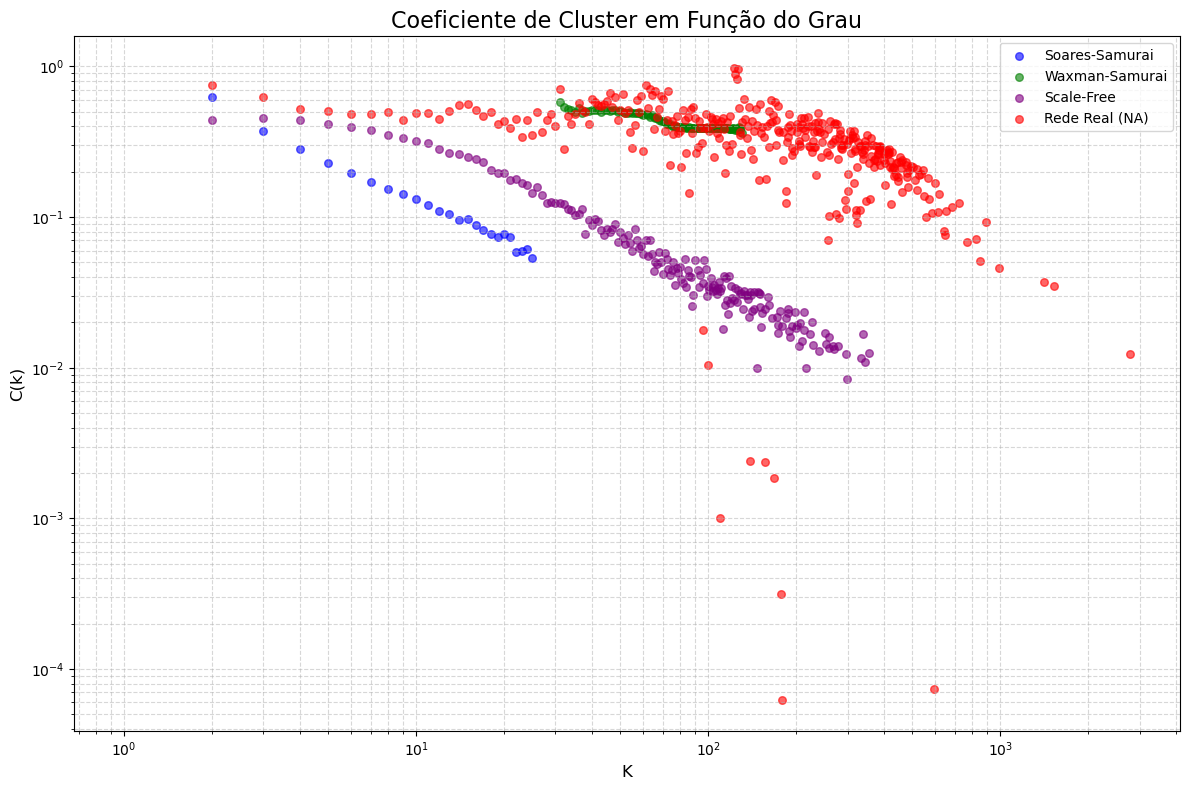

In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais"

# Dicionário com os nomes das redes e os caminhos para os arquivos
arquivos_de_grafos = {
    'Soares-Samurai': os.path.join(path_base, 'soares_photonica.pickle'),
    'Waxman-Samurai': os.path.join(path_base, 'samuraí_photonica.pickle'),
    'Scale-Free': os.path.join(path_base, 'scale_free_photonica.pickle'),
    'Rede Real (NA)': os.path.join(path_base, 'g_photon_real_NA.pickle')
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            # Converte para não-direcionado para o cálculo de clusterização
            G_temp = pickle.load(f)
            if nx.is_directed(G_temp):
                grafos_carregados[nome] = G_temp.to_undirected()
            else:
                grafos_carregados[nome] = G_temp
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado.")
        grafos_carregados[nome] = None


# --- Etapa 2: Função para Calcular e Plotar ---

def plotar_ck_com_fit(ax, G, color, label_prefix, k_min=2, k_max=None):
    """
    Calcula e plota C(k) vs k, e o expoente de decaimento em uma janela [k_min, k_max].
    """
    if not G or G.number_of_nodes() == 0 or not G.edges():
        ax.text(0.5, 0.5, 'Grafo Vazio ou Inválido', ha='center', va='center', transform=ax.transAxes)
        return

    print(f"\nProcessando rede '{label_prefix}' ({G.number_of_nodes()} nós)...")

    # Calcula grau e clusterização
    graus = dict(G.degree())
    clusterizacao = nx.clustering(G)

    df_metricas = pd.DataFrame({'grau': graus, 'clusterizacao': clusterizacao})
    Ck = df_metricas.groupby('grau')['clusterizacao'].mean()
    Ck = Ck[Ck > 0]

    if Ck.empty:
        ax.text(0.5, 0.5, 'C(k) = 0 para todo k', ha='center', va='center', transform=ax.transAxes)
        return

    k_full, Ck_full = Ck.index, Ck.values

    # Plota todos os pontos com aparência base
    ax.scatter(k_full, Ck_full, color=color, alpha=1.0, s=30)

    # Filtra os dados para o ajuste de linha
    k_fit = Ck[ (Ck.index >= k_min) & (Ck.index <= (k_max or float('inf'))) ].index
    Ck_fit = Ck[ (Ck.index >= k_min) & (Ck.index <= (k_max or float('inf'))) ].values

    # Calcula o expoente de decaimento (eta)
    eta = None
    if len(k_fit) > 1:
        try:
            log_k = np.log10(k_fit)
            log_Ck = np.log10(Ck_fit)
            slope, intercept, _, _, _ = stats.linregress(log_k, log_Ck)
            eta = -slope

            fit_line_data = 10**(intercept) * (np.array(k_fit)**(slope))

            k_max_label = '∞' if k_max is None else k_max
            line_label = f'Fit (η ≈ {eta:.2f})\nk ∈ [{k_min}, {k_max_label}]'

            ax.plot(k_fit, fit_line_data, color='black', linestyle='--', linewidth=2.5, label=line_label)
        except Exception as e:
            print(f"  -> Aviso: Não foi possível calcular o fit para '{label_prefix}'. Erro: {e}")

    # Adiciona uma legenda básica se o fit falhar
    if eta is None:
         ax.plot([], [], color=color, marker='o', linestyle='None', label=label_prefix)


# --- Etapa 3: Criar os Gráficos ---
print("\n--- Gerando os gráficos de C(k) vs k ---")

fig, axes = plt.subplots(2, 2, figsize=(18, 16), facecolor='white')
fig.suptitle("Coeficiente de Clusterização Hierárquico C(k)", fontsize=20)
axes = axes.flatten()

# Configuração individual de cada gráfico
plots_para_fazer = {
    0: {'titulo': 'Modelo Soares-Samurai', 'grafo': grafos_carregados.get('Soares-Samurai'), 'k_min': 10, 'k_max': 50},
    1: {'titulo': 'Modelo Waxman-Samurai', 'grafo': grafos_carregados.get('Waxman-Samurai'), 'k_min': 0.1, 'k_max': 0.2},
    2: {'titulo': 'Modelo Scale-Free', 'grafo': grafos_carregados.get('Scale-Free'), 'k_min': 30, 'k_max': 190},
    3: {'titulo': 'Rede Real (NA)', 'grafo': grafos_carregados.get('Rede Real (NA)'), 'k_min': 60, 'k_max': 750}
}

cores = {0: 'blue', 1: 'green', 2: 'purple', 3: 'red'}

for i, conf in plots_para_fazer.items():
    ax = axes[i]
    # Chama a função que agora está definida nesta mesma célula
    plotar_ck_com_fit(ax, conf['grafo'], color=cores[i],
                      label_prefix='C(k)',
                      k_min=conf['k_min'],
                      k_max=conf['k_max'])
    ax.set_title(conf['titulo'], fontsize=16)

# Customização final
for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Grau (k)", fontsize=12)
    ax.set_ylabel("Coeficiente de Clusterização Médio C(k)", fontsize=12)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend()
    ax.grid(True, which="both", ls="--", alpha=1.0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

*K_N_N*

--- Carregando os grafos a partir dos arquivos .pickle ---
-> Arquivo 'soares_photonica.pickle' carregado.
-> Arquivo 'samuraí_photonica.pickle' carregado.
-> Arquivo 'scale_free_photonica.pickle' carregado.
-> Arquivo 'g_photon_real_NA.pickle' carregado.

--- Gerando o gráfico k_nn(k) vs k ---

Processando a rede: Soares-Samurai...
  -> Calculando o grau médio dos vizinhos (k_nn)...

Processando a rede: Waxman-Samurai...
  -> Calculando o grau médio dos vizinhos (k_nn)...

Processando a rede: Scale-Free...
  -> Calculando o grau médio dos vizinhos (k_nn)...

Processando a rede: Rede Real (NA)...
  -> Calculando o grau médio dos vizinhos (k_nn)...


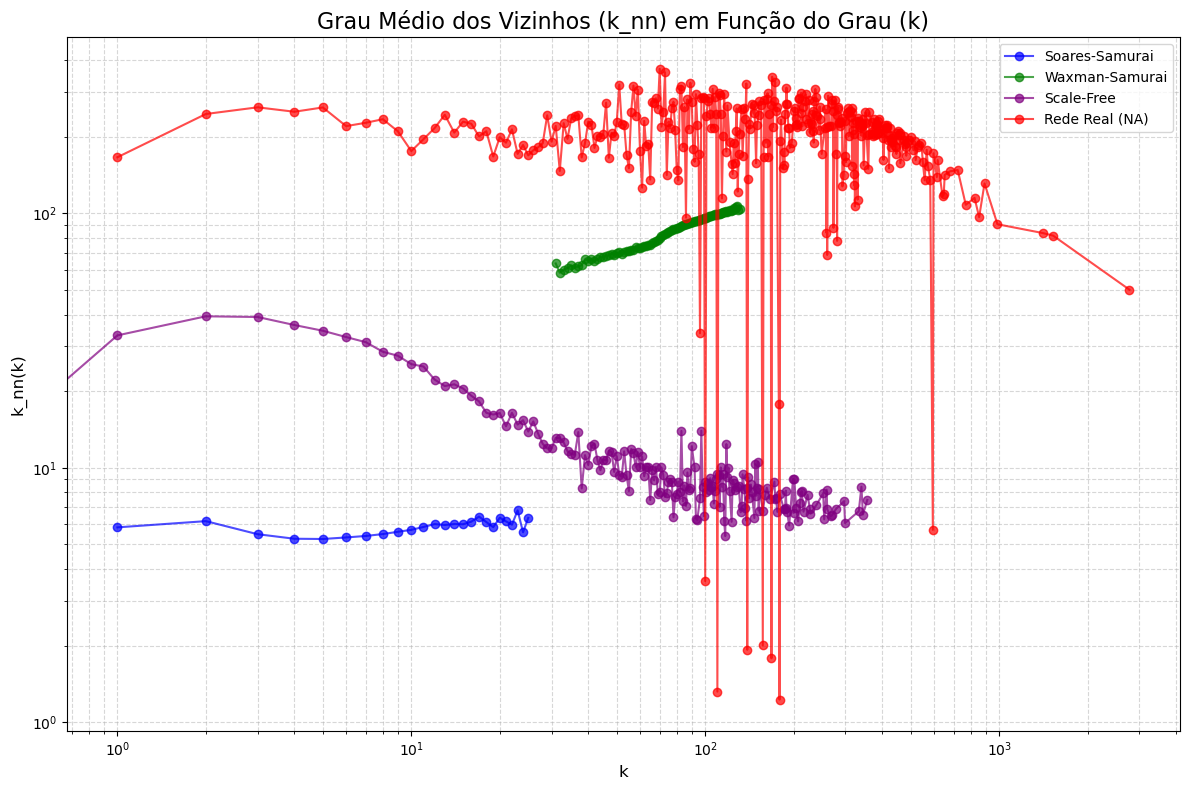

In [ ]:
path_base = r"C:\Users\user\OneDrive\Documentos\IC - Redes Complexas\Dados_redes_reais"

# Dicionário com os nomes das redes e os caminhos para os arquivos
arquivos_de_grafos = {
    'Soares-Samurai': os.path.join(path_base, 'soares_photonica.pickle'),
    'Waxman-Samurai': os.path.join(path_base, 'samuraí_photonica.pickle'),
    'Scale-Free': os.path.join(path_base, 'scale_free_photonica.pickle'),
    'Rede Real (NA)': os.path.join(path_base, 'g_photon_real_NA.pickle')
}

grafos_carregados = {}

print("--- Carregando os grafos a partir dos arquivos .pickle ---")
for nome, caminho in arquivos_de_grafos.items():
    try:
        with open(caminho, 'rb') as f:
            # Converte para não-direcionado, pois a assortatividade é mais comum em grafos não-direcionados
            G_temp = pickle.load(f)
            if nx.is_directed(G_temp):
                grafos_carregados[nome] = G_temp.to_undirected()
            else:
                grafos_carregados[nome] = G_temp
        print(f"-> Arquivo '{os.path.basename(caminho)}' carregado.")
    except FileNotFoundError:
        print(f"AVISO: Arquivo para '{nome}' não encontrado.")
        grafos_carregados[nome] = None


# --- Etapa 2: Calcular k_nn(k) e Plotar ---

print("\n--- Gerando os gráficos k_nn(k) vs k para cada rede ---")

# --- CORREÇÃO: Criar uma grade 2x2 para acomodar 4 gráficos ---
fig, axes = plt.subplots(2, 2, figsize=(16, 14), facecolor='white')
fig.suptitle("Grau Médio dos Vizinhos (k_nn) em Função do Grau (k)", fontsize=20)

# Achatamos a matriz de eixos 2x2 em uma lista simples para facilitar o loop
axes = axes.flatten()

cores = {
    'Soares-Samurai': 'blue',
    'Waxman-Samurai': 'green',
    'Scale-Free': 'purple',
    'Rede Real (NA)': 'red'
}

# Loop para processar e plotar cada grafo em seu próprio subplot
for i, (nome, G) in enumerate(grafos_carregados.items()):
    ax = axes[i] # Pega o eixo do subplot atual (ex: 1º, 2º, 3º ou 4º)
    ax.set_title(nome, fontsize=16) # Define o título do subplot

    if not G or G.number_of_nodes() == 0 or not G.edges():
        ax.text(0.5, 0.5, 'Dados não encontrados', ha='center', va='center', transform=ax.transAxes)
        continue

    print(f"Processando a rede: {nome}...")

    knn = nx.average_degree_connectivity(G)

    if not knn:
        print(f"  -> Não foi possível calcular o k_nn para '{nome}'.")
        continue

    k_sorted = sorted(knn.keys())
    knn_sorted = [knn[k] for k in k_sorted]

    # --- CORREÇÃO: Plota apenas os pontos (marker='o') sem linha (linestyle='None') ---
    ax.loglog(k_sorted, knn_sorted, marker='o', linestyle='None',
              label=nome, color=cores.get(nome, 'black'), alpha=0.7)


# --- Etapa 3: Customização Final de Todos os Gráficos ---
for ax in axes:
    ax.set_xlabel("k (Grau do nó)", fontsize=12)
    ax.set_ylabel("k_nn(k) (Grau Médio dos Vizinhos)", fontsize=12)
    ax.legend()
    ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para o super-título
plt.show()